
# Level 2 – Task 2

## Price Range Analysis

### Objective

The objective of this task is to analyze the relationship between restaurant price ranges and customer ratings.

The analysis includes:

- Identifying the most common price range
- Calculating average ratings for each price range
- Analyzing rating colors
- Exploring restaurant distribution across price categories
- Generating business insights

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/Cleaned_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
price_mapping = {
    1: "Budget",
    2: "Affordable",
    3: "Premium",
    4: "Luxury"
}

df["Price Category"] = df["Price range"].map(price_mapping)

df[["Price range", "Price Category"]].head()

,Price range,Price Category
0,3,Premium
1,3,Premium
2,4,Luxury
3,4,Luxury
4,4,Luxury


In [ ]:
price_distribution = df["Price Category"].value_counts()

price_distribution

,count
Price Category,
Budget,4444
Affordable,3113
Premium,1408
Luxury,586


In [ ]:
price_percentage = (
    df["Price Category"]
    .value_counts(normalize=True)
    *100
).round(2)

price_percentage

,proportion
Price Category,
Budget,46.53
Affordable,32.59
Premium,14.74
Luxury,6.14


In [ ]:
price_summary = pd.DataFrame({
    "Restaurant Count": price_distribution,
    "Percentage": price_percentage
})

price_summary

,Restaurant Count,Percentage
Price Category,,
Budget,4444,46.53
Affordable,3113,32.59
Premium,1408,14.74
Luxury,586,6.14


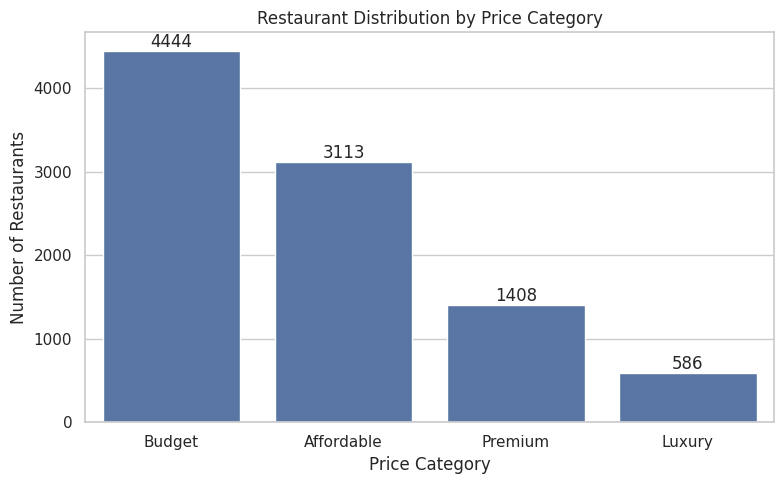

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Price Category",
    order=price_distribution.index
)

plt.title("Restaurant Distribution by Price Category")

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Price Category")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

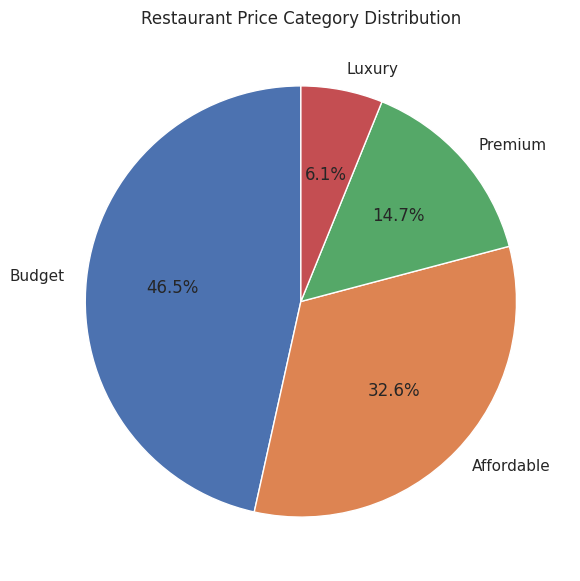

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    price_distribution,
    labels=price_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Restaurant Price Category Distribution")

plt.show()

In [ ]:
print("Most Common Price Category:")

print(df["Price Category"].mode()[0])

Most Common Price Category:
Budget


In [ ]:
average_rating = (
    df.groupby("Price Category")["Aggregate rating"]
    .mean()
    .round(2)
)

average_rating

,Aggregate rating
Price Category,
Affordable,2.94
Budget,2.00
Luxury,3.82
Premium,3.68


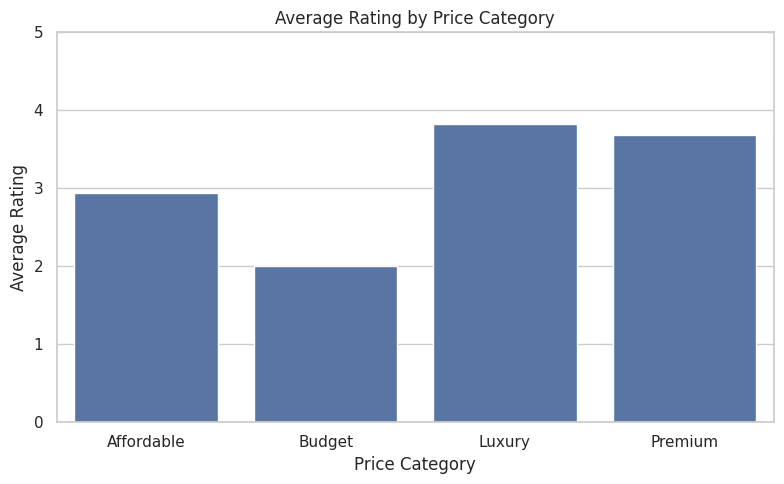

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=average_rating.index,
    y=average_rating.values
)

plt.title("Average Rating by Price Category")

plt.xlabel("Price Category")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.tight_layout()
plt.show()

In [ ]:
rating_color = (
    df.groupby("Rating color")["Aggregate rating"]
    .mean()
    .round(2)
)

rating_color

,Aggregate rating
Rating color,
Dark Green,4.66
Green,4.17
Orange,3.05
Red,2.30
White,0.00
Yellow,3.68


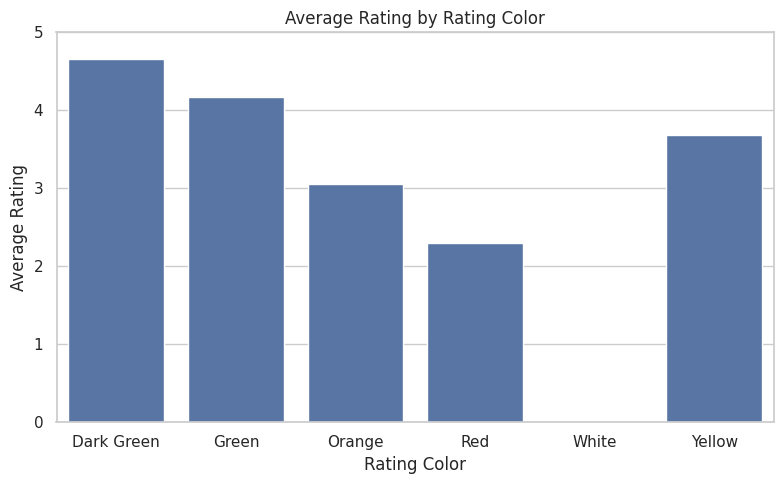

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_color.index,
    y=rating_color.values
)

plt.title("Average Rating by Rating Color")

plt.xlabel("Rating Color")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.tight_layout()
plt.show()

In [ ]:
highest_color = rating_color.idxmax()
highest_rating = rating_color.max()

print("Rating Color with Highest Average Rating:", highest_color)
print("Highest Average Rating:", highest_rating)

Rating Color with Highest Average Rating: Dark Green
Highest Average Rating: 4.66


In [ ]:
rating_color_count = df["Rating color"].value_counts()

rating_color_count

,count
Rating color,
Orange,3737
White,2148
Yellow,2100
Green,1079
Dark Green,301
Red,186


In [ ]:
price_rating = pd.crosstab(
    df["Price Category"],
    df["Rating color"]
)

price_rating

Rating color,Dark Green,Green,Orange,Red,White,Yellow
Price Category,,,,,,
Affordable,69,325,1425,98,402,794
Budget,32,144,1898,62,1700,608
Luxury,74,194,101,6,11,200
Premium,126,416,313,20,35,498


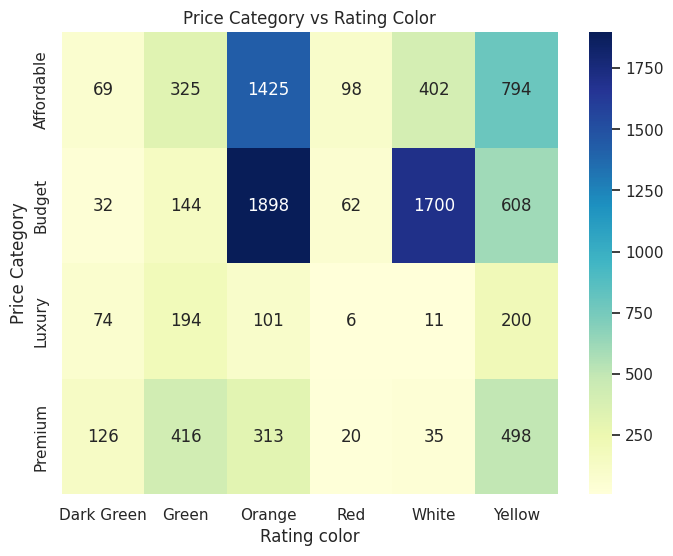

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    price_rating,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Price Category vs Rating Color")

plt.show()

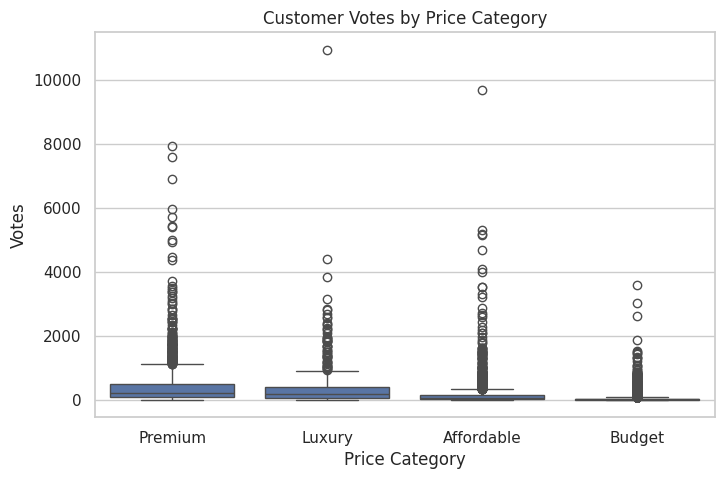

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Price Category",
    y="Votes"
)

plt.title("Customer Votes by Price Category")

plt.show()

# Business Insights

1. Budget restaurants represent the largest share of the dataset, indicating a strong market demand for affordable dining options.

2. Average customer ratings vary across price categories, showing that higher prices do not always guarantee higher customer satisfaction.

3. Rating colors provide a quick visual representation of restaurant performance, with certain colors corresponding to higher average ratings.

4. Customer engagement, measured through votes, differs across price categories, suggesting that pricing influences customer interaction and visibility.

5. Understanding price distribution helps businesses position themselves competitively within the restaurant market.

# Conclusion

Price range analysis revealed important insights into restaurant pricing and customer ratings. Budget restaurants dominate the dataset, while premium and luxury restaurants make up a smaller share.

Average ratings differ across price categories, indicating that pricing alone does not determine customer satisfaction. Rating colors further support the interpretation of restaurant performance and provide an easy way to understand overall quality.

These findings can help restaurant owners optimize pricing strategies and improve customer experiences.

In [ ]:
price_analysis = (
    df.groupby("Price Category")
    .agg(
        Restaurants=("Restaurant ID", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Cost=("Average Cost for two", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .round(2)
)

price_analysis

,Restaurants,Average_Rating,Average_Cost,Average_Votes
Price Category,,,,
Affordable,3113,2.94,596.83,147.61
Budget,4444,2.00,275.18,44.60
Luxury,586,3.82,1848.52,368.60
Premium,1408,3.68,5177.27,443.86
